# MMD SWD analysis

Here we are doing a comparison with visualization to see how MMD compares to SWD in modifiers.

A list of comparison:
1. MMD with small kernel (k=3)
2. MMD with Large kernel (k=75)
3. MMD with multiple kernels (k=3, 15, 75)
4. SWD p=1
5. SWD p=2

On the x axis, there should be the noise modifier
1. noise 1000
2. noise 3000
3. noise 5000
4. noise 7000
5. noise 9000
6. noise 11000
7. noise 13000
8. noise 15000

In [11]:
# Initialization
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

# Paths to run folders (or directly to *_baseline_results.csv).
# Each run should use the same noise sweep and window scheme.
# Example: "output/run_mmd_20260707_141028"

mmd_small_result = r"C:\Users\cxm3593\Academic\Workspace\EventSimilarityAnalysis\output\run_mmd_20260707_141612"   # MMD, single kernel k=3
mmd_large_result = r"C:\Users\cxm3593\Academic\Workspace\EventSimilarityAnalysis\output\run_mmd_20260707_141910"   # MMD, single kernel k=15
mmd_multi_result = r"C:\Users\cxm3593\Academic\Workspace\EventSimilarityAnalysis\output\run_mmd_20260707_142053"   # MMD, kernels k=3, 15, 75
swd_p1_result = r"C:\Users\cxm3593\Academic\Workspace\EventSimilarityAnalysis\output\run_sliced_wasserstein_20260707_142321"      # SWD, p=1
swd_p2_result = r"C:\Users\cxm3593\Academic\Workspace\EventSimilarityAnalysis\output\run_sliced_wasserstein_20260707_142357"      # SWD, p=2

# Which window scheme CSV to read inside each run folder.
WINDOW_SCHEME = "consecutive"  # or "periodic"

# Noise levels expected on the x-axis (must match config modifiers sweep).
NOISE_COUNTS = [1000, 3000, 5000, 7000, 9000, 11000, 13000, 15000]




In [12]:
def load_baseline_results(path, scheme=WINDOW_SCHEME):
    """Load a baseline comparison CSV from a run folder or CSV path."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Result path does not exist: {path}")

    if path.is_dir():
        csv_path = path / f"{scheme}_baseline_results.csv"
    else:
        csv_path = path

    if not csv_path.exists():
        raise FileNotFoundError(f"Baseline results CSV not found: {csv_path}")

    return pd.read_csv(csv_path)


def extract_noise_curve(
    df,
    comparison_set="real_vs_real",
    noise_counts=None,
):
    """Return (noise_counts, mean_distance) for the noise modifier sweep.

    Distances are averaged across comparison windows at each noise level.
    """
    if noise_counts is None:
        noise_counts = NOISE_COUNTS

    mask = (
        (df["comparison_set"] == comparison_set)
        & df["variant"].str.contains("count=", na=False)
        & (df["status"] == "ok")
    )
    subset = df.loc[mask].copy()
    if subset.empty:
        raise ValueError(
            f"No noise-modifier rows found for comparison_set={comparison_set!r}."
        )

    subset["noise_count"] = (
        subset["variant"].str.extract(r"count=(\d+)", expand=False).astype(int)
    )
    grouped = (
        subset.groupby("noise_count", as_index=False)["distance"]
        .mean()
        .set_index("noise_count")
        .reindex(noise_counts)
    )

    missing = grouped["distance"].isna()
    if missing.any():
        missing_counts = grouped.index[missing].tolist()
        print(f"Warning: missing distances for noise counts: {missing_counts}")

    return np.asarray(noise_counts, dtype=int), grouped["distance"].to_numpy()


In [13]:
def plot_noise_curve(
    label,
    path,
    scheme=WINDOW_SCHEME,
    comparison_set="real_vs_real",
    noise_counts=None,
    figsize=(8.0, 5.0),
    color="tab:blue",
    marker="o",
    title=None,
    save_path=None,
    show=True,
):
    """Plot mean distance vs noise count for a single metric run."""
    if not path:
        raise ValueError(f"Path not set for {label!r}.")
    if noise_counts is None:
        noise_counts = NOISE_COUNTS

    df = load_baseline_results(path, scheme=scheme)
    xs, ys = extract_noise_curve(
        df,
        comparison_set=comparison_set,
        noise_counts=noise_counts,
    )

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(xs, ys, marker=marker, linestyle="-", color=color, label=label)
    ax.set_xlabel("Noise event count")
    ax.set_ylabel("Mean distance to baseline")
    ax.set_title(
        title
        or f"{label} under add_noise modifier [{scheme}, {comparison_set}]"
    )
    ax.set_xticks(noise_counts)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax


def plot_mmd_swd_comparison(
    runs,
    scheme=WINDOW_SCHEME,
    comparison_set="real_vs_real",
    noise_counts=None,
    figsize=(10.0, 6.0),
    title=None,
    save_path=None,
    show=True,
):
    """Plot mean distance vs noise count for several metric runs."""
    if noise_counts is None:
        noise_counts = NOISE_COUNTS

    fig, ax = plt.subplots(figsize=figsize)
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
    markers = ["o", "s", "^", "D", "v"]

    plotted = 0
    for index, (label, path) in enumerate(runs):
        if not path:
            print(f"Skipping {label!r}: path not set.")
            continue

        df = load_baseline_results(path, scheme=scheme)
        xs, ys = extract_noise_curve(
            df,
            comparison_set=comparison_set,
            noise_counts=noise_counts,
        )
        ax.plot(
            xs,
            ys,
            marker=markers[index % len(markers)],
            linestyle="-",
            color=colors[index % len(colors)],
            label=label,
        )
        plotted += 1

    if plotted == 0:
        raise ValueError("No runs were plotted. Fill in at least one result path.")

    ax.set_xlabel("Noise event count")
    ax.set_ylabel("Mean distance to baseline")
    ax.set_title(
        title
        or f"Metric comparison under add_noise modifier [{scheme}, {comparison_set}]"
    )
    ax.set_xticks(noise_counts)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax


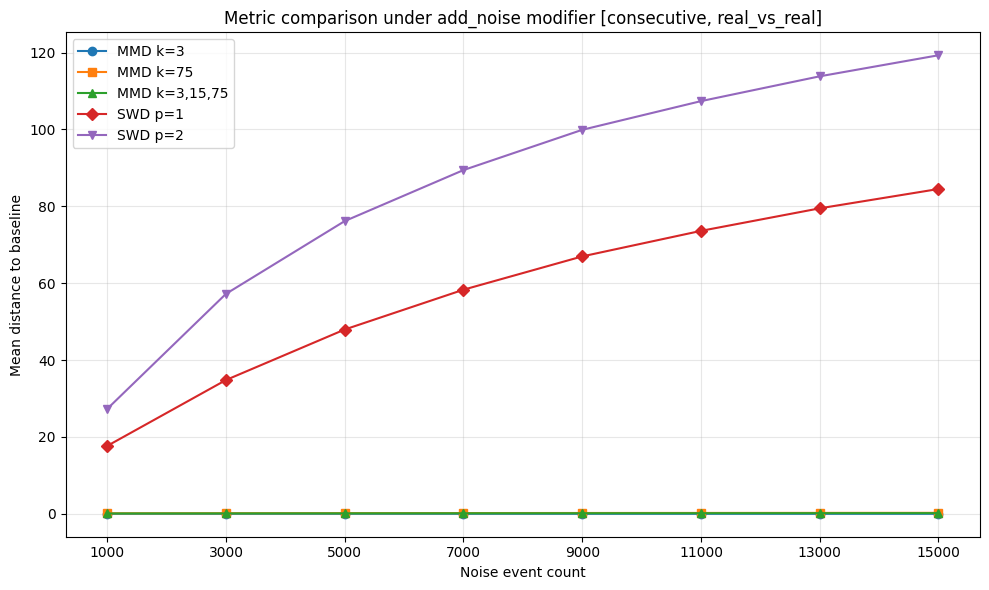

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Metric comparison under add_noise modifier [consecutive, real_vs_real]'}, xlabel='Noise event count', ylabel='Mean distance to baseline'>)

In [14]:
runs = [
    ("MMD k=3", mmd_small_result),
    ("MMD k=75", mmd_large_result),
    ("MMD k=3,15,75", mmd_multi_result),
    ("SWD p=1", swd_p1_result),
    ("SWD p=2", swd_p2_result),
]

plot_mmd_swd_comparison(
    runs,
    scheme=WINDOW_SCHEME,
    comparison_set="real_vs_real",
    # save_path="mmd_swd_noise_comparison.png",
)


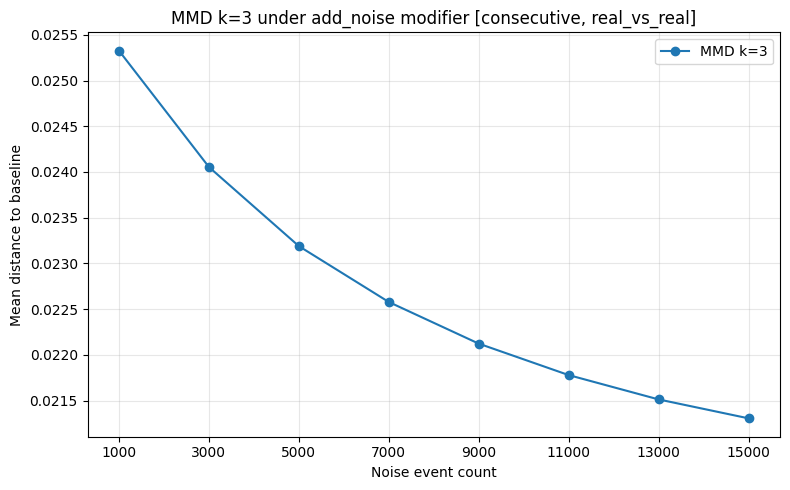

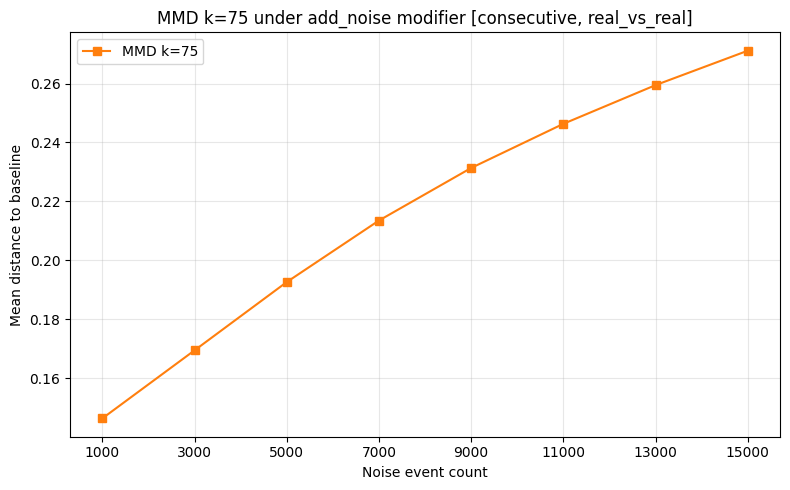

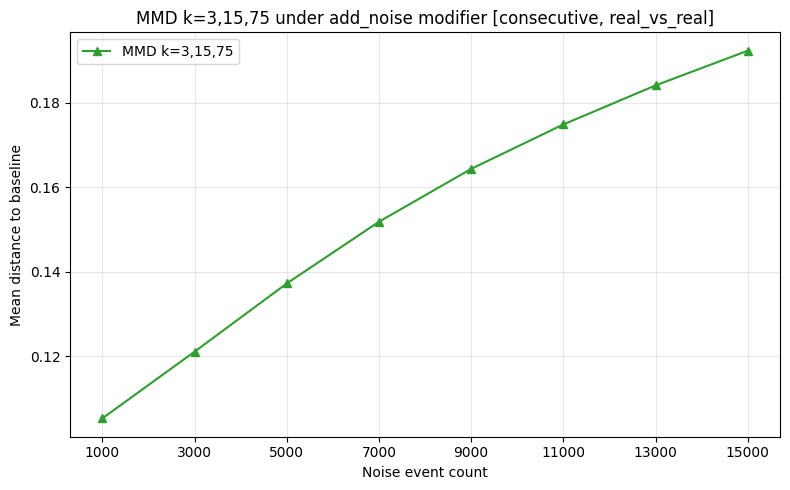

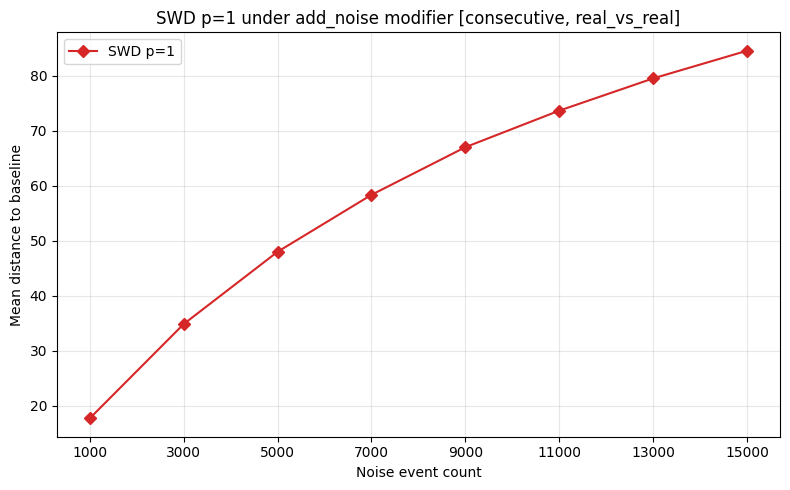

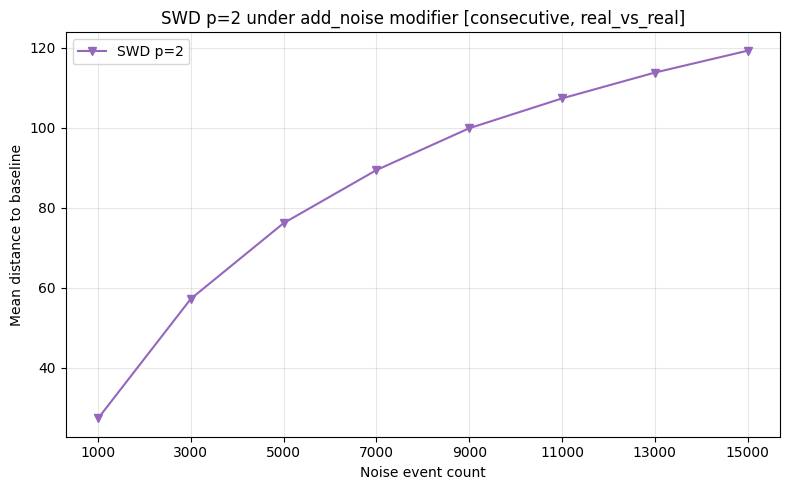

In [15]:
# Individual plots (one figure per metric run)
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
markers = ["o", "s", "^", "D", "v"]

for index, (label, path) in enumerate(runs):
    if not path:
        print(f"Skipping {label!r}: path not set.")
        continue

    plot_noise_curve(
        label,
        path,
        scheme=WINDOW_SCHEME,
        comparison_set="real_vs_real",
        color=colors[index % len(colors)],
        marker=markers[index % len(markers)],
        # save_path=f"{label.replace(' ', '_').replace(',', '')}_noise_curve.png",
    )
